# GO/STOP! - Object Detection 시스템 만들기 


** GO/STOP 결과는 제일 밑에 있습니다.



| 파라미터                 | 현재 값 | 조정 방향 및 효과                                                                                                        |
|----------------------|------|-------------------------------------------------------------------------------------------------------------------|
| confidence_threshold | 0.1  | 높임 (0.25 ~ 0.5): 가짜 탐지(False Positive)가 많을 때 사용합니다. 현재 0.1은 매우 낮은 편이라, 확실하지 않은 객체도 다 보여주게 됩니다. 너무 낮으면 노이즈가 심해집니다. |
| nms_iou_threshold    | 0.5  | 낮춤 (0.3 ~ 0.45): 한 객체에 박스가 여러 개 겹쳐 나올 때 사용합니다. 값이 낮을수록 겹친 박스들을 더 공격적으로 제거합니다.                                     |
| max_detections       | 100  | 유지 또는 조정: 한 이미지에 나올 수 있는 최대 객체 수입니다. 일반적인 도로 상황에서는 100이면 충분합니다.                                                   |


1. "너무 엉뚱한 곳에 박스가 생겨요" (정밀도 우선)
 - confidence_threshold를 0.3~0.5 정도로 높여보세요.

2. "자동차 한 대에 박스가 두세 개씩 겹쳐요"
 - nms_iou_threshold를 0.4 정도로 낮춰보세요. NMS(Non-Maximum Suppression)는 가장 점수가 높은 박스 하나만 남기고 나머지는 지우는 과정
3. "멀리 있는 작은 차도 다 잡고 싶어요"
 - confidence_threshold=0.1은 작은 객체를 잡기에는 유리하지만, 배경을 물체로 오인할 확률이 높습니다.


In [ ]:
## 주요 난제

* 저대비 보행자 검출 (흰 옷/흰 배경 이슈)
문제 : 배경과 객체의 색상이 유사할 때 CNN의 피처 맵에서 객체성(Objectness) 신호가 소멸되는 현상 확인.
    -> RandomGrayscale을 도입하여 학습시켜봄
    -> 오히려 학습효과가 떨어지고 다른 객체 검출(특히 사람)이 적어짐

    2-> 앵커 박스 확인시, 어떤 학습된 모델도 사람을 검출하지 못하여 파라미터 튜닝으로 해결될 문제가 아님을..
    -> 배추세기

* 정답 바운딩 박스의 사이즈보다 작은 사이즈의 예측 박스
문제 : 객체의 특징점을 더욱 확대되어 검출하여, 넓은 영역의 정답영역에 못 미치게 바운딩 박스가 생성됨.
    -> 앵커박스를 최대한 확인해 봄
    -> 다양한 사이즈의 앵커 박스가 있고, 조건에 부합하는 앵커박스를 고르게 할 수 있어 보였지만 
       이미지 상으로는 이미 선택되어진 후보군 중의 선택 바운딩 박스가 더 적합하여 
       작업을 추가할 수 없었음

    2-> 실제 이미지를 확인했을 때, 가로세로 사이즈가 300px를 넘지않아 stop 이 아닌 go로 판단



* 회고
3월까지 다른 일이 생겨 많은 실험을 시도하거나, 원시 데이터를 확인 하지 못 했으나
원시 데이터와 클래스 라벨링에 대해서 더욱 분석하여
모델의 학습까지 분석해봤으면 더욱 효과적인 분석이 되었을 것으로 보인다.

** 1개의 잘못된 라벨링에 얽매여서 전체적인 모델의 관점을 흐리지 않기 **

In [1]:
import torch
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import os
import torch.nn.functional as F
import torch.nn as nn
from torchvision import transforms
import torchvision.models as models
from torchvision.ops import nms

import matplotlib.pyplot as plt


# 클래스별 색상 매핑
CLASS_COLORS = {
    'Car': (255, 0, 0),           # 빨강
    'Van': (255, 128, 0),         # 주황
    'Truck': (255, 255, 0),       # 노랑
    'Pedestrian': (0, 255, 0),    # 초록
    'Person_sitting': (0, 255, 128),  # 연두
    'Cyclist': (0, 128, 255),     # 하늘색
    'Tram': (128, 0, 255),        # 보라
    'Misc': (255, 0, 255)         # 
}

def load_model(checkpoint_path='checkpoints/best.pth', num_classes=8, device='cuda'):
    """학습된 모델 로드"""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    backbone = get_resnet50_backbone(pretrained=False)
    model = RetinaNet(num_classes=num_classes, backbone=backbone)
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"모델 로드 완료: {checkpoint_path}")
        print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}, Loss: {checkpoint.get('loss', 'N/A'):.4f}")
    except FileNotFoundError:
        print(f"체크포인트를 찾을 수 없습니다: {checkpoint_path}")

    
    model = model.to(device)
    model.eval()
    
    decoder = DecodePredictions(
        num_classes=num_classes,
        confidence_threshold=0.25,
        nms_iou_threshold=0.5,
        max_detections=100
    )
    
    return model, decoder, device
    

회고 
* 3월까지 시간이 좀 부족해서 많은 내용을 검토 해 ㅂㅎ

In [2]:
class DecodePredictions(nn.Module):
    """
    RetinaNet 예측을 실제 bounding boxes로 디코딩    
    Args:
        num_classes: 클래스 개수
        confidence_threshold: 신뢰도 임계값
        nms_iou_threshold: NMS IoU 임계값
        max_detections: 최대 탐지 개수
        box_variance: Anchor box 인코딩 시 사용된 분산
    """
    
    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)
    
    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        """Anchor boxes와 예측값으로부터 실제 boxes 디코딩"""
        boxes = box_predictions * self._box_variance.to(box_predictions.device)
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:]
            ],
            dim=-1
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed
    
    def forward(self, images, predictions):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
            predictions: (B, num_anchors, 4 + num_classes) 모델 예측
        Returns:
            List of tuples (boxes, scores, classes) for each image in batch
        """
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        anchor_boxes = anchor_boxes.to(predictions.device)
        
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        
        batch_results = []
        
        for i in range(boxes.shape[0]):
            selected_boxes = []
            selected_scores = []
            selected_classes = []
            
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                
                if mask.sum() == 0:
                    continue
                
                class_boxes = boxes[i, mask]
                class_scores_filtered = class_scores[mask]
                
                # NMS
                keep = nms(class_boxes, class_scores_filtered, self.nms_iou_threshold)
                
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores_filtered[keep])
                selected_classes.append(torch.full((len(keep),), class_id, dtype=torch.int64))
            
            if len(selected_boxes) > 0:
                all_boxes = torch.cat(selected_boxes, dim=0)
                all_scores = torch.cat(selected_scores, dim=0)
                all_classes = torch.cat(selected_classes, dim=0)

                # 최대 탐지 개수 제한
                if len(all_boxes) > self.max_detections:
                    top_scores, top_indices = torch.topk(all_scores, self.max_detections)
                    all_boxes = all_boxes[top_indices]
                    all_scores = top_scores
                    all_classes = all_classes[top_indices]
            else:
                all_boxes = torch.empty((0, 4), device=boxes.device)
                all_scores = torch.empty((0,), device=boxes.device)
                all_classes = torch.empty((0,), dtype=torch.int64, device=boxes.device)
            
            batch_results.append((all_boxes, all_scores, all_classes))
        return batch_results

In [3]:
def visualize_detection(
    image_path,
    checkpoint_path='checkpoints/best.pth',
    output_path=None,
    img_size=(384, 1280),
    show_scores=True,
    min_score=0.3,
    show_drive_assist=True
):
    """
    이미지에 탐지 결과 시각화
    Args:
        image_path: 입력 이미지 경로
        checkpoint_path: 모델 체크포인트
        output_path: 저장 경로 (None이면 화면에 표시)
        img_size: 모델 입력 크기
        show_scores: 점수 표시 여부
        show_drive_assist: 자율주행 보조 표시 여부
        min_score: 최소 표시 점수
    Returns:
        PIL Image with bounding boxes
    """
    # 클래스 이름
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 
                  'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    # 모델 로드
    model, decoder, device = load_model(checkpoint_path)
    # 원본 이미지 로드
    image = Image.open(image_path).convert('RGB')
    original_size = image.size  # (width, height)
    # 스케일 계산
    scale_w = img_size[1] / original_size[0]
    scale_h = img_size[0] / original_size[1]
    
    # 전처리
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # 추론
    with torch.no_grad():
        predictions = model(image_tensor)
        decoded = decoder(image_tensor, predictions)
    
    boxes, scores, classes = decoded[0]
    boxes = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    classes = classes.cpu().numpy()
    
    # 원본 이미지에 그리기
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # 폰트 설정 (한글 지원)
    try:
        font = ImageFont.truetype("malgun.ttf", 20)  # Windows
    except:
        font = ImageFont.load_default()
    
    detection_count = 0
    class_counts = {}
    
    # 각 탐지 결과 그리기
    for i, (box, score, cls) in enumerate(zip(boxes, scores, classes)):
        if score < min_score:
            continue
        detection_count += 1
        
        # 원본 좌표로 변환
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h
        
        # 클래스 정보
        class_name = class_names[cls]
        color = CLASS_COLORS.get(class_name, (255, 255, 255))
        # 카운트
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # 바운딩 박스 그리기
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        # 라벨 텍스트
        if show_scores:
            label = f"{class_name} {score:.2f}"
        else:
            label = class_name
        
        # 라벨 배경
        text_bbox = draw.textbbox((x1, y1 - 25), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1 - 25), label, fill=(255, 255, 255), font=font)
    
    print(f"\n 탐지 완료!")
    print(f"   총 {detection_count}개 객체 탐지")
    if class_counts:
        print("   클래스별 개수:")
        for cls_name, count in sorted(class_counts.items()):
            print(f"     - {cls_name}: {count}")

    # 저장 또는 표시
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        draw_image.save(output_path)
        print(f"\n결과 저장: {output_path}")
    else:
        # plt.figure(figsize=(10, 8))
        # plt.imshow(draw_image)
        # plt.axis('on') # 좌표축 표시 (박스 위치 확인용)
        # plt.show()     # 여기서의 .show()는 웹 브라우저 내장 출력이라 에러가 안 납니다.
        # draw_image.show()
        # 이후에 다시 실행
        plt.imshow(draw_image)
        plt.show()
    
    return draw_image

In [4]:
import argparse
import glob
import random

parser = argparse.ArgumentParser(description='RetinaNet 추론 시각화')
parser.add_argument('--image', type=str, 
                   default=None,
                   help='이미지 경로 (지정하지 않으면 랜덤)')
parser.add_argument('--image_dir', type=str,
                   default=os.path.join(os.getenv("HOME"), "work/object_detection/data/Kitti/raw/testing/image_2"),
                   help='랜덤 선택할 이미지 디렉토리')
parser.add_argument('--checkpoint', type=str, 
                   default=os.path.join(os.getenv("HOME"),'work/object_detection/checkpoints/best.pth'),
                   help='모델 체크포인트')
parser.add_argument('--output', type=str, 
                   default='result.png',
                   help='결과 저장 경로')

args, unknown = parser.parse_known_args()

In [5]:
def get_resnet50_backbone(pretrained=True):
    """
    ResNet50 백본 생성 (C3, C4, C5 feature maps 반환)
    Returns:
        ResNet50Backbone 모듈
    """
    resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    
    class ResNet50Backbone(nn.Module):
        def __init__(self, resnet_model):
            super(ResNet50Backbone, self).__init__()
            self.conv1 = resnet_model.conv1
            self.bn1 = resnet_model.bn1
            self.relu = resnet_model.relu
            self.maxpool = resnet_model.maxpool
            self.layer1 = resnet_model.layer1  # C2
            self.layer2 = resnet_model.layer2  # C3 (256 channels)
            self.layer3 = resnet_model.layer3  # C4 (512 channels)
            self.layer4 = resnet_model.layer4  # C5 (1024 channels)
        
        def forward(self, x):
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)
            x = self.layer1(x)
            c3 = self.layer2(x)  # 1/8
            c4 = self.layer3(c3)  # 1/16
            c5 = self.layer4(c4)  # 1/32            
            return c3, c4, c5
    return ResNet50Backbone(resnet)

In [6]:
class RetinaNet(nn.Module):
    """
    RetinaNet 객체 탐지 모델
    Args:
        num_classes: 객체 클래스 개수 (배경 제외)
        backbone: Feature 추출을 위한 백본 네트워크
    """

    def __init__(self, num_classes, backbone=None):
        super(RetinaNet, self).__init__()        
        if backbone is None:
            backbone = get_resnet50_backbone(pretrained=True)
        
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes
        # Prior probability for rare class
        prior_probability = 0.01
        bias_value = -np.log((1 - prior_probability) / prior_probability)
        # 9 = 3 aspect ratios * 3 scales
        self.cls_head = build_head(9 * num_classes, bias_value)
        self.box_head = build_head(9 * 4, 0.0)
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지        
        Returns:
            predictions: (B, num_anchors, 4 + num_classes)
                - 처음 4개: bbox 회귀 예측
                - 나머지: 클래스 로짓
        """
        features = self.fpn(images)
        N = images.size(0)
        cls_outputs = []
        box_outputs = []
        
        for feature in features:
            box_output = self.box_head(feature)
            cls_output = self.cls_head(feature)
            
            # Reshape: (B, C, H, W) -> (B, H*W*9, 4 or num_classes)
            box_output = box_output.permute(0, 2, 3, 1).contiguous()
            box_output = box_output.view(N, -1, 4)
            cls_output = cls_output.permute(0, 2, 3, 1).contiguous()
            cls_output = cls_output.view(N, -1, self.num_classes)
            
            box_outputs.append(box_output)
            cls_outputs.append(cls_output)
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

In [7]:
class FeaturePyramid(nn.Module):
    """
    Feature Pyramid Network
    ResNet 백본에서 추출한 feature maps를 피라미드 구조로 변환
    """
    
    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # 1x1 convolution for lateral connections
        self.conv_c3_1x1 = nn.Conv2d(512, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, kernel_size=1, stride=1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, kernel_size=1, stride=1, padding=0)
        # 3x3 convolution for smoothing
        self.conv_c3_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        # Extra layers for P6, P7
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, kernel_size=3, stride=2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')
    
    def forward(self, images):
        """
        Args:
            images: (B, 3, H, W) 입력 이미지
        Returns:
            p3, p4, p5, p6, p7: 5개 레벨의 feature maps
        """
        # ResNet backbone feature extraction
        c3_output, c4_output, c5_output = self.backbone(images)        
        # Top-down pathway
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p3_output = self.conv_c3_1x1(c3_output)
        # Add upsampled features (크기를 맞춰서 더하기)
        p5_upsampled = F.interpolate(p5_output, size=p4_output.shape[-2:], mode='nearest')
        p4_output = p4_output + p5_upsampled
        p4_upsampled = F.interpolate(p4_output, size=p3_output.shape[-2:], mode='nearest')
        p3_output = p3_output + p4_upsampled
        # Apply 3x3 smoothing
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        # Extra coarse levels
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(F.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output


In [8]:
def build_head(output_filters, bias_init, num_convs=4):
    """
    분류 또는 박스 회귀 헤드 구축
    Args:
        output_filters: 출력 채널 수
        bias_init: 마지막 레이어의 bias 초기화 값
        num_convs: convolution 레이어 개수
    """
    layers = []
    
    for _ in range(num_convs):
        layers.append(nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1))
        layers.append(nn.ReLU(inplace=True))
    # 최종 예측 레이어
    layers.append(nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1))
    
    # Weight 초기화
    for layer in layers:
        if isinstance(layer, nn.Conv2d):
            nn.init.normal_(layer.weight, mean=0.0, std=0.01)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)
    # 마지막 레이어 bias 초기화
    if isinstance(bias_init, (int, float)):
        nn.init.constant_(layers[-1].bias, bias_init)
    
    return nn.Sequential(*layers)

In [9]:
class AnchorBox:
    """
    RetinaNet을 위한 Anchor Box 생성기
    Args:
        aspect_ratios: Anchor의 가로세로 비율 리스트
        scales: Anchor 크기 스케일 리스트
        areas: 각 피라미드 레벨별 기본 영역
    """
    
    def __init__(
        self,
        aspect_ratios=[0.5, 1.0, 2.0],
        scales=[2 ** 0, 2 ** (1/3), 2 ** (2/3)],
        areas=[32.0**2, 64.0**2, 128.0**2, 256.0**2, 512.0**2]
    ):
        self.aspect_ratios = aspect_ratios
        self.scales = scales
        self.areas = areas
        
        self._num_anchors = len(aspect_ratios) * len(scales)
        self._strides = [2 ** i for i in range(3, 8)]  # [8, 16, 32, 64, 128]
        self._anchor_dims = self._compute_dims()
    
    def _compute_dims(self):
        """각 피라미드 레벨과 aspect ratio/scale 조합별 anchor 크기 계산"""
        anchor_dims_all = []
        
        for area in self.areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area / ratio))
                anchor_width = area / anchor_height
                
                dims = torch.stack([anchor_width, anchor_height], dim=-1)
                dims = dims.unsqueeze(0).unsqueeze(0)
                
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        
        return anchor_dims_all
    
    def _get_anchors(self, feature_height, feature_width, level):
        """특정 피라미드 레벨의 anchor boxes 생성"""
        # 그리드 중심점 생성
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        
        centers = torch.stack(torch.meshgrid(rx, ry, indexing='xy'), dim=-1)
        centers = centers * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        
        # Anchor 크기 정보
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        
        # [center_x, center_y, width, height] 형식
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)
    
    def get_anchors(self, image_height, image_width):
        """이미지 크기에 대한 모든 피라미드 레벨의 anchors 생성"""
        anchors = [
            self._get_anchors(
                torch.ceil(torch.tensor(image_height / (2 ** i))).int().item(),
                torch.ceil(torch.tensor(image_width / (2 ** i))).int().item(),
                i
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)

In [10]:
def convert_to_corners(boxes):
    """중심점 형식을 corner 형식으로 변환"""
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0,
         boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1
    )

def convert_to_xywh(boxes):
    """Corner 형식을 중심점 형식으로 변환"""
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

In [11]:
# # result 폴더 생성
# os.makedirs('result', exist_ok=True)

# # 20번 반복
# for i in range(20):
#     # 이미지 경로 결정
#     if args.image is None:
#         # 랜덤 선택
#         image_files = glob.glob(os.path.join(args.image_dir, '*.png'))
#         image_files += glob.glob(os.path.join(args.image_dir, '*.jpg'))
#         image_path = random.choice(image_files)
#     # 출력 경로 설정
#     output_path = f'result/result_{i+1:02d}.png'
#     # 단일 이미지 처리
#     visualize_detection(
#         image_path,
#         checkpoint_path=args.checkpoint,
#         output_path=output_path,
#         show_scores=True
#     )

In [12]:
import torch

print(torch.__version__)

2.7.1+cu118


In [13]:
img_path = os.getenv('HOME')+'/work/object_detection/data/stop_1.png'
checkpoint_path = '/home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth'
# def self_drive_assist(img_path, size_limit=300):
#     # 코드 구현
#         # 정지조건에 맞으면 return "Stop"
#         # 아닌 경우 return "Go"
#     # 예외 상황을 포함하기위해서 어떤 기준이 또 필요할까요!?

# print(self_drive_assist(img_path))

In [14]:
import os

def test_system(func):
    work_dir = os.getenv('HOME')+'/work/object_detection/data'
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        
        pred = func(image_path, checkpoint_path=checkpoint_path, show_scores=True)
        print("pred:", pred)
        if pred == answer:
            score += 10
        
        print(f"{image_path}입니다.")
        # visualize_detection(
        #     image_path,
        #     checkpoint_path=args.checkpoint,
        #     show_scores=True
        # )
        
    print(f"{score}점입니다.")

# test_system(self_drive_assist)

모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 4, Loss: 0.3746

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_1.png는 Go 입니다.
   총 0개 객체 탐지


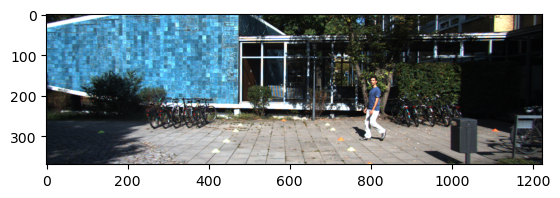

In [15]:
img_path = os.getenv('HOME')+'/work/object_detection/data/stop_1.png'


def self_drive_assist(img_path, size_limit=300, checkpoint_path='checkpoints/best.pth',
                      img_size=(384, 1280), min_score=0.3,
                      
    output_path=None,
    show_scores=True, 
    show_drive_assist=True
                     ):
    situation = "Go"
    # 코드 구현
        # 정지조건에 맞으면 return "Stop"
        # 아닌 경우 return "Go"
    # 예외 상황을 포함하기위해서 어떤 기준이 또 필요할까요!?

    
    """
    이미지에 탐지 결과 시각화
    Args:
        image_path: 입력 이미지 경로
        checkpoint_path: 모델 체크포인트
        output_path: 저장 경로 (None이면 화면에 표시)
        img_size: 모델 입력 크기
        show_scores: 점수 표시 여부
        show_drive_assist: 자율주행 보조 표시 여부
        min_score: 최소 표시 점수
    Returns:
        PIL Image with bounding boxes
    """
    # 클래스 이름
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 
                  'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    # 모델 로드
    model, decoder, device = load_model(checkpoint_path)
    # 원본 이미지 로드
    image = Image.open(img_path).convert('RGB')
    original_size = image.size  # (width, height)
    # 스케일 계산
    scale_w = img_size[1] / original_size[0]
    scale_h = img_size[0] / original_size[1]
    
    # 전처리
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # 추론
    with torch.no_grad():
        predictions = model(image_tensor)
        decoded = decoder(image_tensor, predictions)
    
    boxes, scores, classes = decoded[0]
    
        
    boxes = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    classes = classes.cpu().numpy()
    
    # 원본 이미지에 그리기
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # 폰트 설정 (한글 지원)
    try:
        font = ImageFont.truetype("malgun.ttf", 20)  # Windows
    except:
        font = ImageFont.load_default()
    
    detection_count = 0
    class_counts = {}
    
    # 각 탐지 결과 그리기
    for i, (box, score, cls) in enumerate(zip(boxes, scores, classes)):
        if score < min_score:
            continue
        detection_count += 1
        
        # 원본 좌표로 변환
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h
        
        # if classes in range(0,3):
        width = x2 - x1
        heigth = y2 - y1
        if width >= 300 or heigth >= 300:
            situation = "Stop"
        # box_size = int(( x2-x1 ) * ( y2 - y1 ))
        # print("x1, y1", str(int(x1)), str(int(y1)))
        # print("      x2, y2", str(int(x2)), str(int(y2)))
        print(f"width:{width}, heigth:{heigth}")
        # print("box_size", str(int(box_size)))
        # print("class:", str(int(cls)))
                
        # 클래스 정보
        class_name = class_names[cls]
        if class_name in ['Pedestrian', 'Person_sitting', 'Cyclist']:
            situation = "Stop"
            
        color = CLASS_COLORS.get(class_name, (255, 255, 255))
        # 카운트
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # 바운딩 박스 그리기
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        # 라벨 텍스트
        if show_scores:
            label = f"{class_name} {score:.2f}"
        else:
            label = class_name
        
        # 라벨 배경
        text_bbox = draw.textbbox((x1, y1 - 25), label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1 - 25), label, fill=(255, 255, 255), font=font)
    
    print(f"\n 탐지 완료!")
    print(f"{img_path}는 {situation} 입니다.")
    print(f"   총 {detection_count}개 객체 탐지")
    if class_counts:
        print("   클래스별 개수:")
        for cls_name, count in sorted(class_counts.items()):
            print(f"     - {cls_name}: {count}")

    # 저장 또는 표시
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        draw_image.save(output_path)
        print(f"\n결과 저장: {output_path}")
    else:
        # plt.figure(figsize=(10, 8))
        # plt.imshow(draw_image)
        # plt.axis('on') # 좌표축 표시 (박스 위치 확인용)
        # plt.show()     # 여기서의 .show()는 웹 브라우저 내장 출력이라 에러가 안 납니다.
        # draw_image.show()
        # 이후에 다시 실행
        plt.imshow(draw_image)
        plt.show()
    pass
    return situation
situation = self_drive_assist(img_path, checkpoint_path=args.checkpoint)

# visualize_detection(
#     img_path,
#     checkpoint_path=args.checkpoint,
#     show_scores=True
# )


/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:57.54998779296875, heigth:177.7711639404297

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_1.png는 Stop 입니다.
   총 1개 객체 탐지
   클래스별 개수:
     - Cyclist: 1


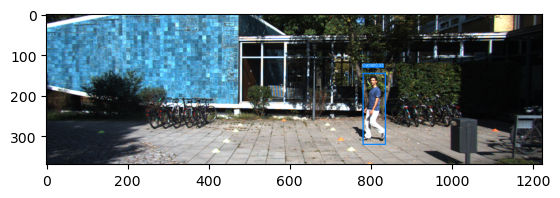

pred:Stop, answer: Stop
/home/jovyan/work/object_detection/data/stop_1.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_2.png는 Go 입니다.
   총 0개 객체 탐지


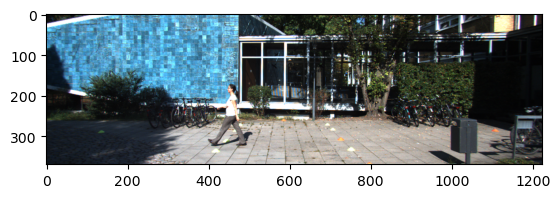

pred:Go, answer: Stop
/home/jovyan/work/object_detection/data/stop_2.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:81.59210205078125, heigth:55.17869567871094
width:215.52728271484375, heigth:172.92514038085938
width:68.9039306640625, heigth:52.290069580078125

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_3.png는 Go 입니다.
   총 3개 객체 탐지
   클래스별 개수:
     - Car: 3


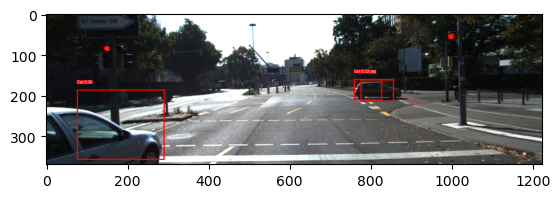

pred:Go, answer: Stop
/home/jovyan/work/object_detection/data/stop_3.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:164.1873321533203, heigth:141.39697265625
width:70.21490478515625, heigth:72.50730895996094
width:218.77728271484375, heigth:161.18167114257812
width:74.92449951171875, heigth:52.4927978515625
width:86.51614379882812, heigth:57.92572021484375
width:71.51229858398438, heigth:53.19207763671875
width:73.38433837890625, heigth:89.0166015625
width:68.9825439453125, heigth:86.38661193847656
width:294.44195556640625, heigth:267.3701171875
width:67.781494140625, heigth:78.64764404296875
width:247.15191650390625, heigth:327.1495361328125
width:70.12322998046875, heigth:84.72085571289062
width:68.58685302734375, heigth:81.28132629394531
width:74.8037109375, heigth:82.02676391601562

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_4.png는 S

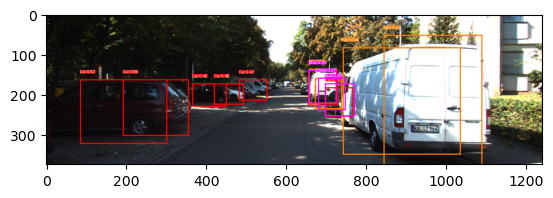

pred:Stop, answer: Stop
/home/jovyan/work/object_detection/data/stop_4.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:97.330810546875, heigth:79.26087951660156
width:220.7906494140625, heigth:192.59414672851562
width:311.241943359375, heigth:209.72972106933594
width:43.39459228515625, heigth:32.57167053222656
width:68.995849609375, heigth:74.54263305664062
width:46.407745361328125, heigth:49.432159423828125
width:33.1763916015625, heigth:33.80870056152344
width:47.38018798828125, heigth:82.86344909667969
width:34.4287109375, heigth:65.35234069824219
width:47.90966796875, heigth:87.44111633300781
width:72.24871826171875, heigth:93.31694030761719
width:40.47332763671875, heigth:74.00178527832031

 탐지 완료!
/home/jovyan/work/object_detection/data/stop_5.png는 Stop 입니다.
   총 12개 객체 탐지
   클래스별 개수:
     - Car: 7
     - Misc: 1
     - Van: 4


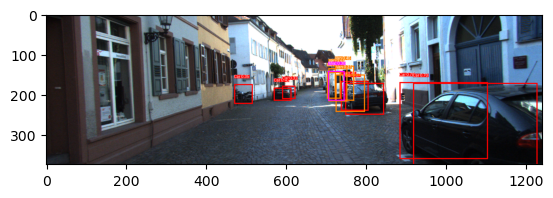

pred:Stop, answer: Stop
/home/jovyan/work/object_detection/data/stop_5.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:22.72088623046875, heigth:38.225494384765625
width:35.09808349609375, heigth:31.60382080078125
width:133.86244201660156, heigth:107.54899597167969
width:52.97314453125, heigth:55.72900390625
width:139.93862915039062, heigth:118.01898193359375
width:135.30465698242188, heigth:108.58830261230469

 탐지 완료!
/home/jovyan/work/object_detection/data/go_1.png는 Go 입니다.
   총 6개 객체 탐지
   클래스별 개수:
     - Car: 2
     - Tram: 1
     - Truck: 2
     - Van: 1


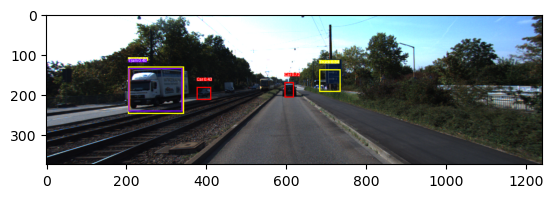

pred:Go, answer: Go
/home/jovyan/work/object_detection/data/go_1.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:47.3096923828125, heigth:41.88665771484375
width:31.0643310546875, heigth:59.88642883300781
width:31.966064453125, heigth:54.830902099609375

 탐지 완료!
/home/jovyan/work/object_detection/data/go_2.png는 Go 입니다.
   총 3개 객체 탐지
   클래스별 개수:
     - Car: 1
     - Misc: 1
     - Van: 1


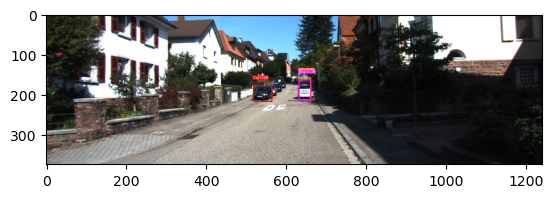

pred:Go, answer: Go
/home/jovyan/work/object_detection/data/go_2.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:64.6610107421875, heigth:43.719268798828125

 탐지 완료!
/home/jovyan/work/object_detection/data/go_3.png는 Go 입니다.
   총 1개 객체 탐지
   클래스별 개수:
     - Car: 1


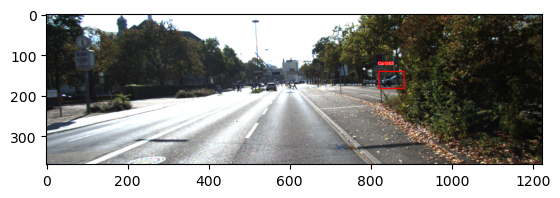

pred:Go, answer: Go
/home/jovyan/work/object_detection/data/go_3.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:83.56982421875, heigth:79.546142578125
width:84.78790283203125, heigth:89.65141296386719

 탐지 완료!
/home/jovyan/work/object_detection/data/go_4.png는 Go 입니다.
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 1
     - Van: 1


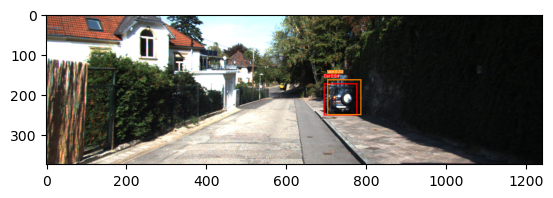

pred:Go, answer: Go
/home/jovyan/work/object_detection/data/go_4.png입니다.
/home/jovyan/work/object_detection/checkpoints/best.pth
모델 로드 완료: /home/jovyan/work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep02/best04_80.pth
   Epoch: 4, Loss: 0.3074
width:141.02101135253906, heigth:99.49920654296875
width:180.0191192626953, heigth:128.3813934326172
width:69.48834228515625, heigth:52.204925537109375
width:85.043212890625, heigth:65.63468933105469
width:112.09336853027344, heigth:82.3583984375
width:145.69113159179688, heigth:143.8995819091797
width:65.68179321289062, heigth:51.31703186035156

 탐지 완료!
/home/jovyan/work/object_detection/data/go_5.png는 Go 입니다.
   총 7개 객체 탐지
   클래스별 개수:
     - Car: 7


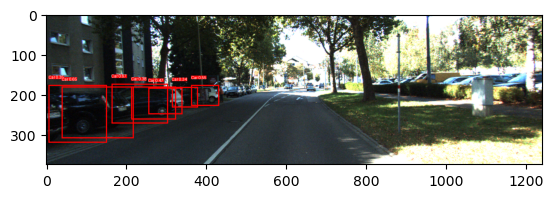

pred:Go, answer: Go
/home/jovyan/work/object_detection/data/go_5.png입니다.
80점입니다.


In [16]:
import os

def test_system(func):
    work_dir = os.getenv('HOME')+'/work/object_detection/data'
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = work_dir + '/' + image_file
        print(args.checkpoint)
        pred = func(image_path, 
                    checkpoint_path=checkpoint_path, 
                    show_scores=True

                    # img_path, size_limit=300, checkpoint_path='checkpoints/best.pth',
                    # img_size=(384, 1280), min_score=0.3,
                      
                    # output_path=None,
                    # show_scores=True, 
                    # show_drive_assist=True
                   )
        if pred == answer:
            score += 10
        
        print(f"pred:{pred}, answer: {answer}")
        print(f"{image_path}입니다.")
        # visualize_detection(
        #     image_path,
        #     checkpoint_path=args.checkpoint,
        #     show_scores=True
        # )
        
    print(f"{score}점입니다.")

test_system(self_drive_assist)